# **UTP Kecerdasan Artifisial Lanjut 2026**


Nama: Hassan Nashrallah

NIM: 245150200111025

Kelas: F



# Tata Tertib Ujian Tengah Praktikum (UTP) KAL 2026

## 1. Kehadiran dan Pengawasan
- Peserta wajib masuk ke Google Meet tepat waktu.
- Kamera harus menyala (on-cam) sepanjang durasi ujian.
- Tidak ada perpanjangan waktu bagi peserta yang datang terlambat.

## 2. Integritas Akademik
- Dilarang bekerja sama selama ujian.
- Dilarang menyontek dalam bentuk apa pun.
- Dilarang menggunakan bantuan kecerdasan buatan (AI) seperti ChatGPT, Gemini, atau Claude.

## 3. Batasan Teknologi
Penggunaan library dibatasi hanya pada:
- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `sklearn.preprocessing`
- `sklearn.metrics`
- `train_test_split` dari `sklearn.model_selection`

## 4. Teknis Pengerjaan
- Durasi pengerjaan: **120 menit**
- Jawaban harus ditulis pada template yang telah disiapkan.
- Pastikan seluruh kode program dapat dieksekusi tanpa error agar mendapatkan nilai maksimal.

## 5. Ketentuan Pengumpulan
- Berkas dikumpulkan dalam format **.ipynb** melalui Google Classroom.
- Format penamaan file:

## **Soal**

### Klasifikasi Keamanan Konsumsi Jamur (Mushroom Classification)

Dalam soal ini, mahasiswa diminta untuk melakukan analisis dan klasifikasi terhadap berbagai spesies jamur berdasarkan karakteristik fisiknya untuk memprediksi apakah jamur tersebut **layak dikonsumsi (edible)** atau **beracun (poisonous)**.

Studi kasus ini bertujuan untuk memberikan sistem pendukung keputusan bagi ahli biologi atau masyarakat umum guna meminimalisir risiko keracunan jamur melalui identifikasi otomatis yang akurat.

---

### Tujuan Pengerjaan

Dalam praktikum ini, mahasiswa diharapkan untuk:

1. **Preprocessing Data**: Melakukan pembersihan data, menangani *missing values* pada fitur tertentu (seperti *cap-surface*, *gill-attachment*, dll), serta melakukan encoding pada data kategorikal.
2.  **Eksplorasi Data (EDA)**: Menganalisis fitur fisik jamur (misalnya diameter tudung, warna batang, atau habitat) yang paling signifikan dalam membedakan jamur beracun dan layak konsumsi.
3.  **Model Decision Tree**: Membangun model Decision Tree secara manual (*from scratch*) menggunakan kriteria *Gini Index* atau *Information Gain*.
4.  **Evaluasi & Analisis**: Mengukur performa model menggunakan metrik akurasi dan menganalisis stabilitas pohon keputusan yang dihasilkan.

---

### Context Study Case

Laboratorium Mikrobiologi Universitas Brawijaya sedang melakukan penelitian luas terhadap 61.069 sampel jamur hipotetis yang dikembangkan berdasarkan 173 spesies jamur di alam liar.

Anda berperan sebagai AI Researcher yang ditugaskan untuk mengolah **Secondary Mushroom Dataset**. Dataset ini memiliki karakteristik unik dibandingkan dataset klasik, di antaranya:
* **Target**: Biner (*edible* = e, *poisonous* = p).
* **Fitur Metrik**: Terdapat variabel kontinu seperti *cap-diameter*, *stem-height*, dan *stem-width*.
* **Fitur Nominal**: Karakteristik fisik seperti *cap-shape*, *gill-color*, hingga *habitat* dan *season*.

Tugas utama Anda adalah mengembangkan model Decision Tree secara manual (*from scratch*) untuk memahami mekanika internal algoritma dalam menangani fitur campuran (nominal dan metrical) serta memastikan model tidak mengalami *overfitting* pada data simulasi yang besar ini.

---

### Kriteria Penilaian

* **Pemahaman Konsep (20%)**: Ketepatan dalam menjelaskan kriteria percabangan dan struktur node.
* **Kebenaran Implementasi (50%)**: Kode fungsi `buat_tree` dan `prediksi` dapat berjalan tanpa error dan menangani logika rekursif dengan benar.
* **Evaluasi dan Output (15%)**: Kemampuan menampilkan visualisasi pohon (pprint) dan menghitung akurasi prediksi.
* **Kualitas Analisis (15%)**: Kedalaman analisis mengenai fitur mana yang paling informatif (memiliki Gain tertinggi) dalam klasifikasi jamur.

---

# Bagian 1: Persiapan dan Pemrosesan Data
1. Impor Data: Muat dataset `mushroom_dataset.csv` ke dalam DataFrame menggunakan pandas.
2. Pemisahan Data:
   - Bagi dataset menjadi data latih (80%) dan data uji (20%)
   - Gunakan `train_test_split` dari `sklearn.model_selection`
   - Tampilkan informasi dasar dataset (`head`, `info`, dan `describe`).
   - Berapa jumlah data dan fitur pada dataset?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

### Load Dataset

In [2]:
# from google.colab import files
# uploaded = files.upload()

In [3]:
# Upload dataset terlebih dahulu sebelum dibaca!
# Melewati baris yang jumlah kolomnya tidak sesuai
file = 'C:/Users/hassa/OneDrive/Dokumen/praktikumz/kal-praktikum/data/mushroom_dataset.csv'
df = pd.read_csv(file, delimiter=';', on_bad_lines='skip')

print(f"Data berhasil dimuat. Total baris: {len(df)}")

Data berhasil dimuat. Total baris: 61069


### Tampilkan Informasi Data

In [4]:
# Isi jawaban disini
display(df.head())
display(df.info())
display(df.describe())

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

None

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


- Apa tipe data dari setiap kolom?

  Jawaban: Dari 21 kolom, ada 3 kolom yang dengan tipe data float64, yakni cap-diameter, stem-width, dan stem-height. Sedangkan sisa kolom lainnya memiliki tipe data object.

#### Tunjukan nilai-nilai unik pada masing-masing fitur kategorikal!

In [5]:
# 1. Mengambil daftar nama kolom yang bertipe 'object'
kolom = df.select_dtypes(include='object').columns

# 2. Menampilkan daftar nama kolomnya
display(kolom)

# 3. Melakukan looping menggunakan daftar nama tersebut
for nama_kolom in kolom:
    print(f"{nama_kolom}: {df[nama_kolom].nunique()}")

Index(['class', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color',
       'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season'],
      dtype='object')

class: 2
cap-shape: 7
cap-surface: 11
cap-color: 12
does-bruise-or-bleed: 2
gill-attachment: 7
gill-spacing: 3
gill-color: 12
stem-root: 5
stem-surface: 8
stem-color: 13
veil-type: 1
veil-color: 6
has-ring: 2
ring-type: 8
spore-print-color: 7
habitat: 8
season: 4


- Berapa jumlah kategori pada masing-masing fitur?
  
  Jawaban:

### Tampilkan Statistik Data

In [6]:
df.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


* Jelaskan apa yang bisa anda simpulkan pada hasil diatas?

  Jawaban: Jika dilihat dari hasil di atas, distribusi ketiga fitur ini lebih condong ke kanan atau right-skewed karena nilai mean lebih besar dari mediannya. Beberapa fitur juga memiliki outlier dengan besarnya perbedaan dari nilai tertinggi (max) dengan nilai kuartil tiganya (Q3). Meski begitu, ketiga fitur tidak memiliki missing value.

### EDA Sederhana

##### Tunjukan Keseimbangan Data

In [7]:
for nama_kolom in kolom:
    print(df[nama_kolom].value_counts())

class
p    33888
e    27181
Name: count, dtype: int64
cap-shape
x    26934
f    13404
s     7164
b     5694
o     3460
p     2598
c     1815
Name: count, dtype: int64
cap-surface
t    8196
s    7608
y    6341
h    4974
g    4724
d    4432
e    2584
k    2303
i    2225
w    2150
l    1412
Name: count, dtype: int64
cap-color
n    24218
y     8543
w     7666
g     4420
e     4035
o     3656
r     1782
u     1709
p     1703
k     1279
b     1230
l      828
Name: count, dtype: int64
does-bruise-or-bleed
f    50479
t    10590
Name: count, dtype: int64
gill-attachment
a    12698
d    10247
x     7413
p     6001
e     5648
s     5648
f     3530
Name: count, dtype: int64
gill-spacing
c    24710
d     7766
f     3530
Name: count, dtype: int64
gill-color
w    18521
n     9645
y     9546
p     5983
g     4118
f     3530
o     2909
k     2375
r     1399
e     1066
u     1023
b      954
Name: count, dtype: int64
stem-root
s    3177
b    3177
r    1412
f    1059
c     706
Name: count, dtype: int64
st

##### Analisis Hubungan Fitur Kategorikal

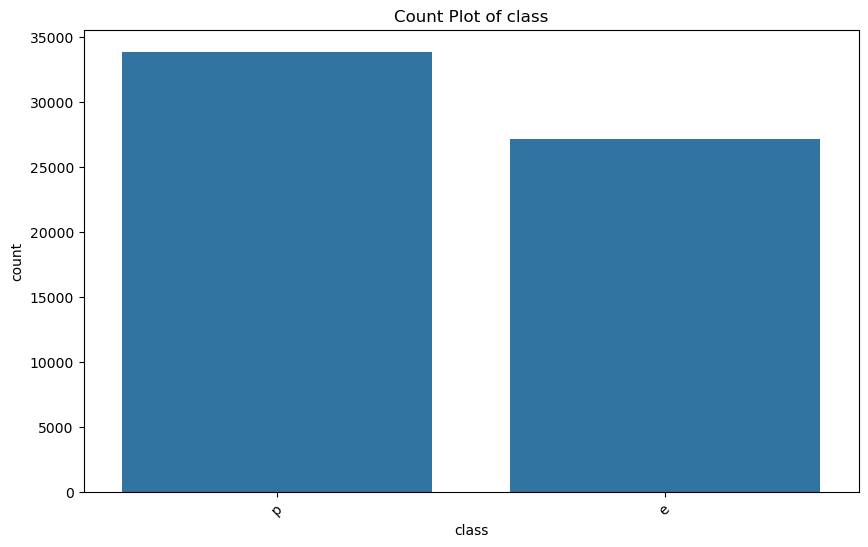

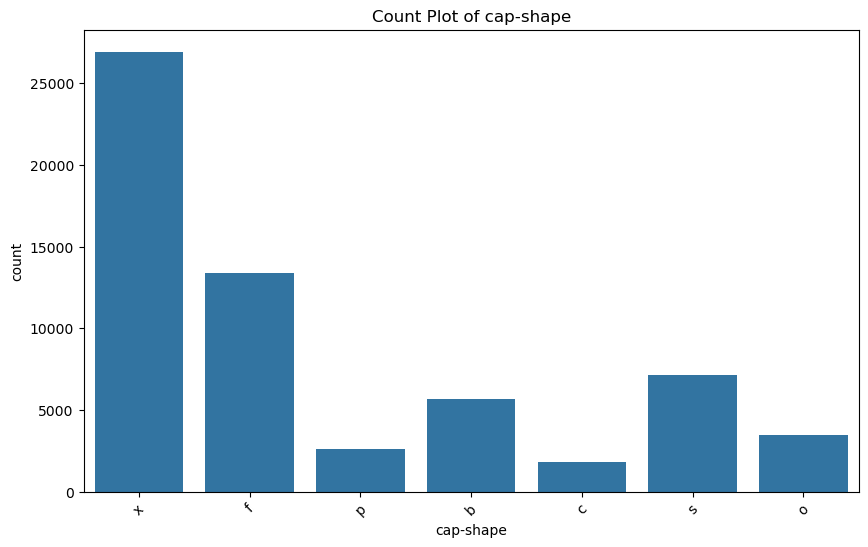

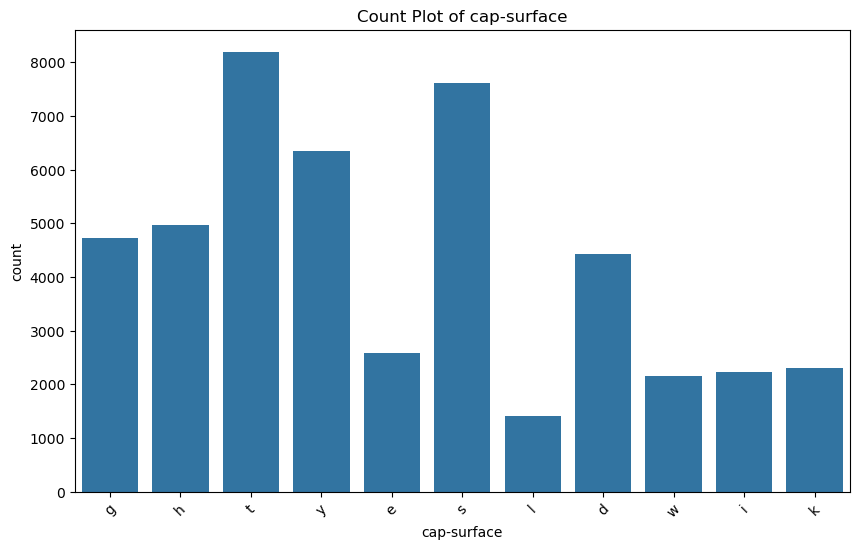

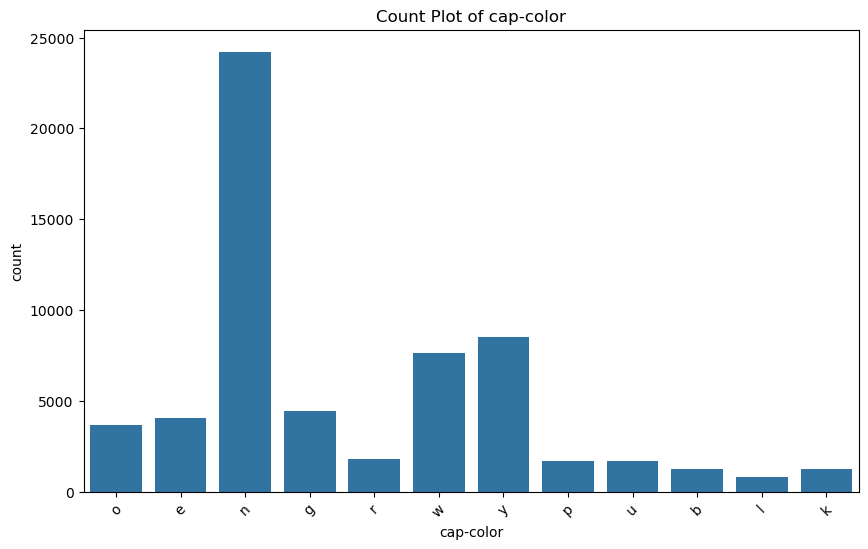

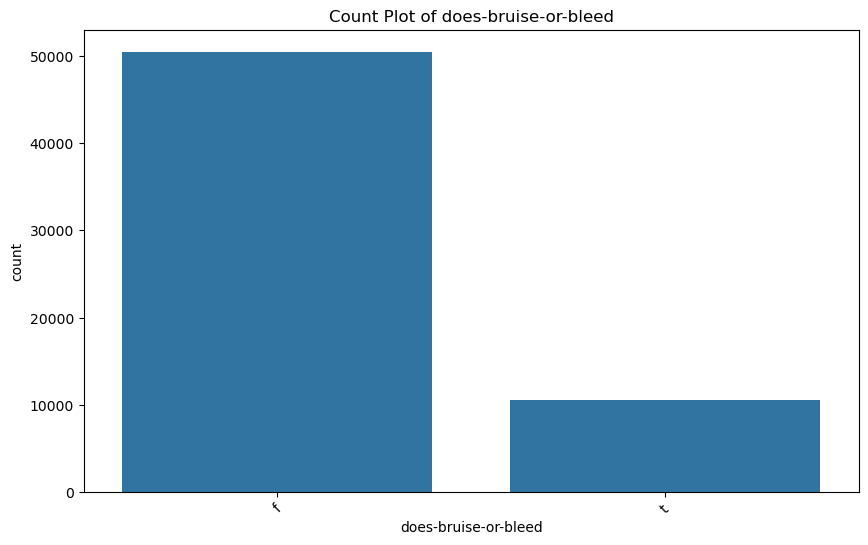

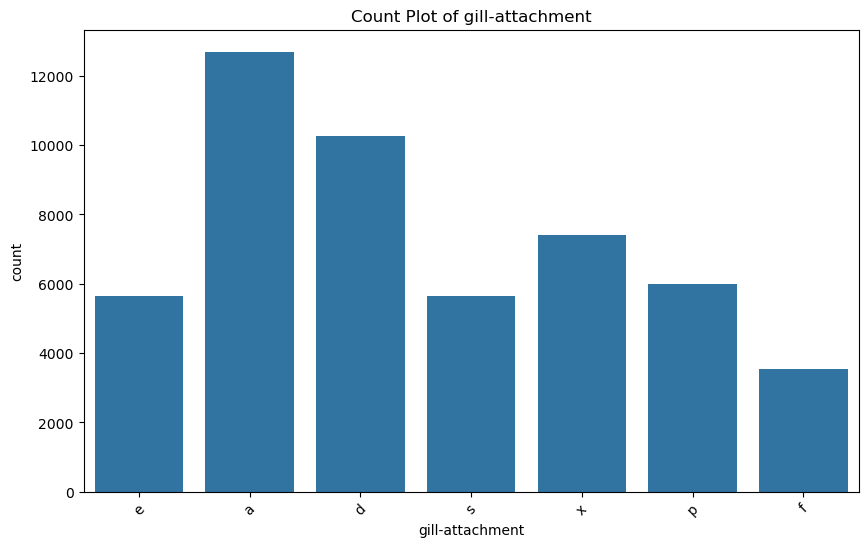

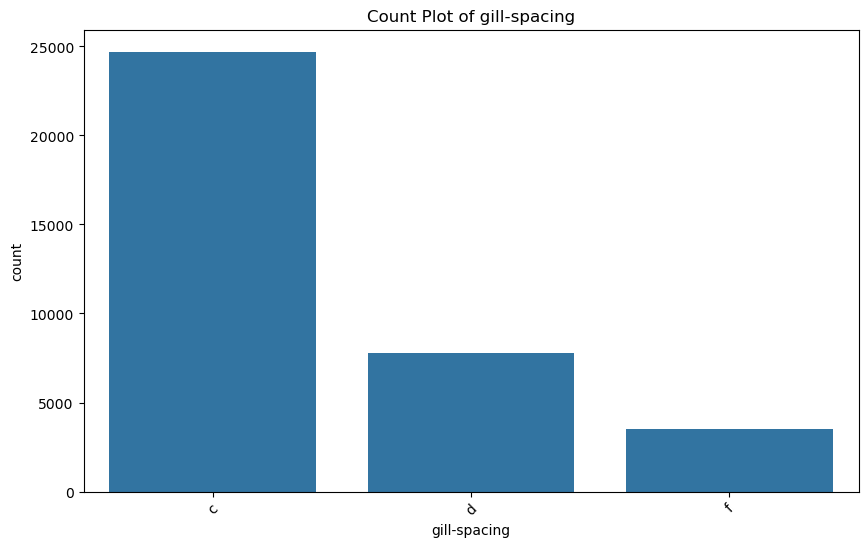

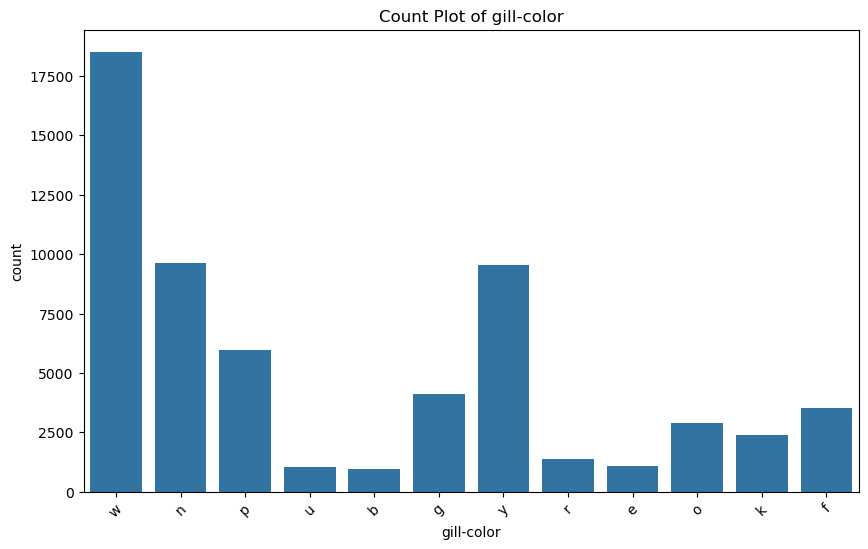

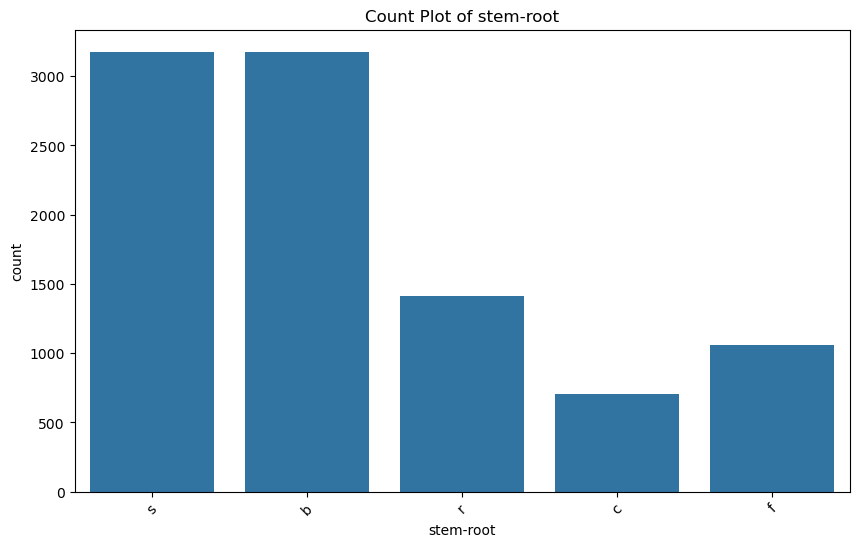

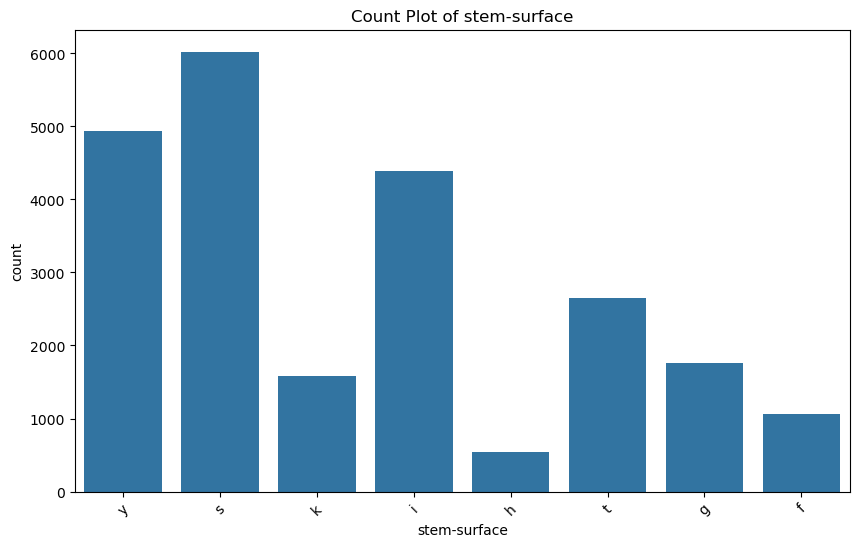

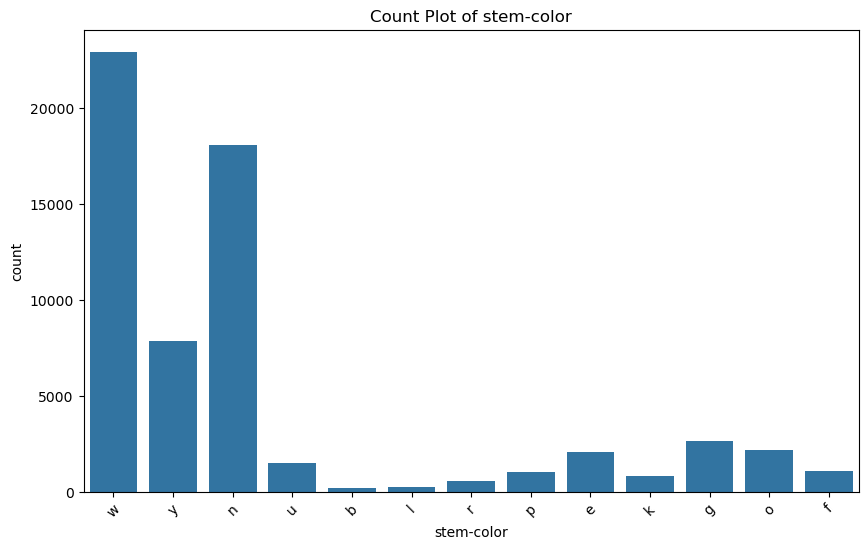

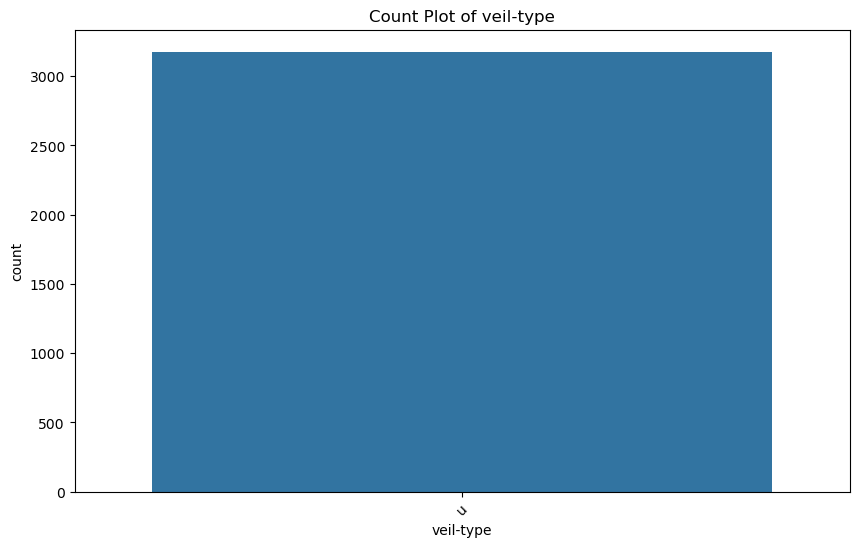

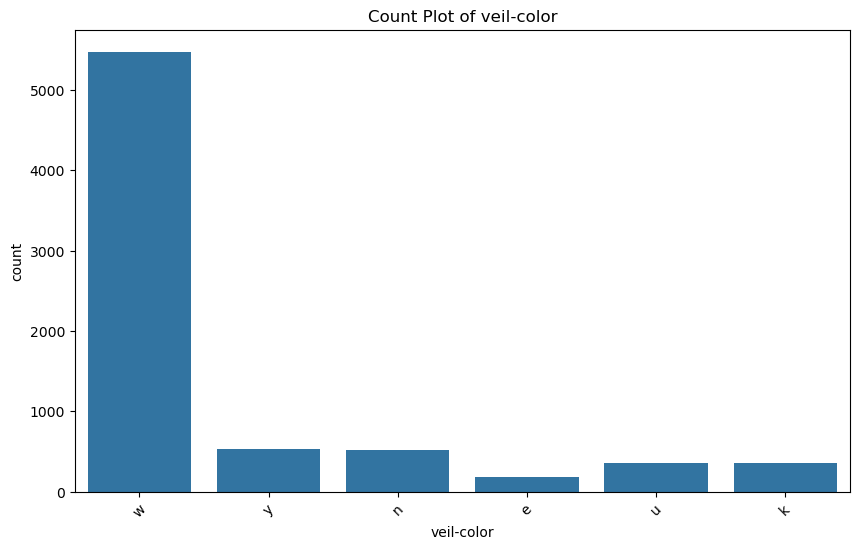

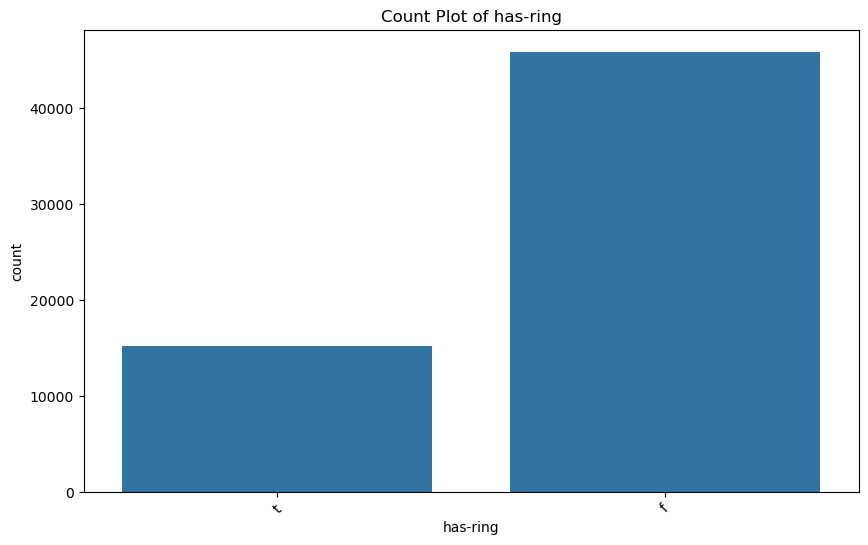

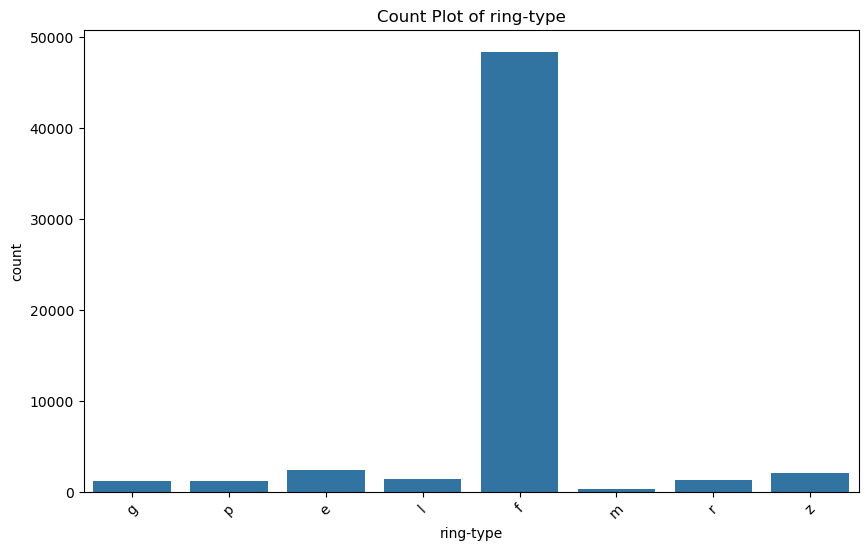

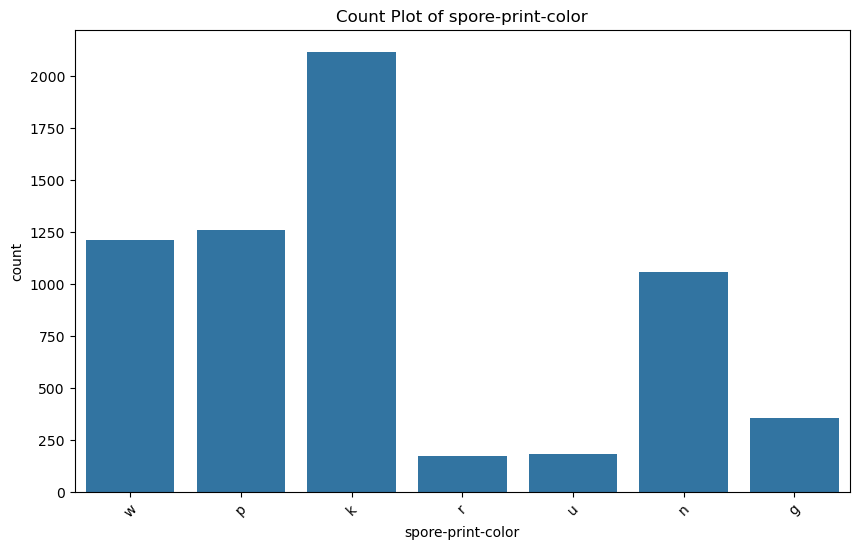

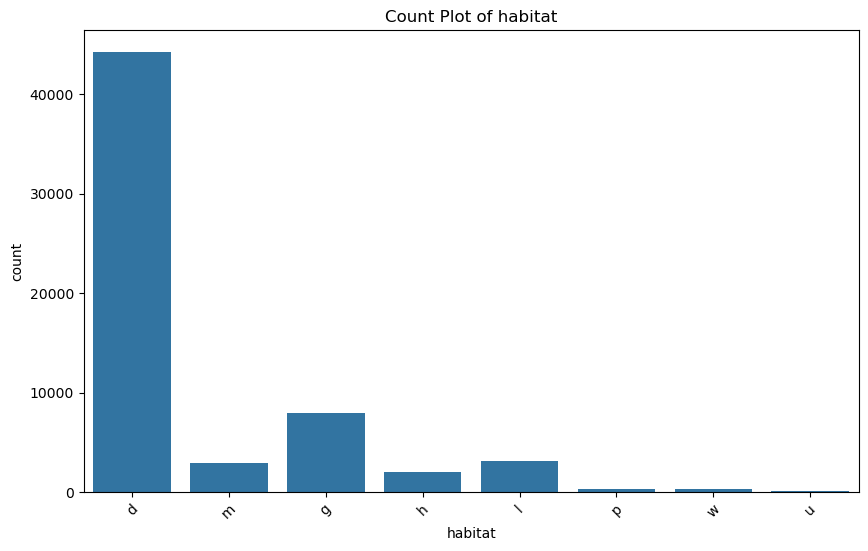

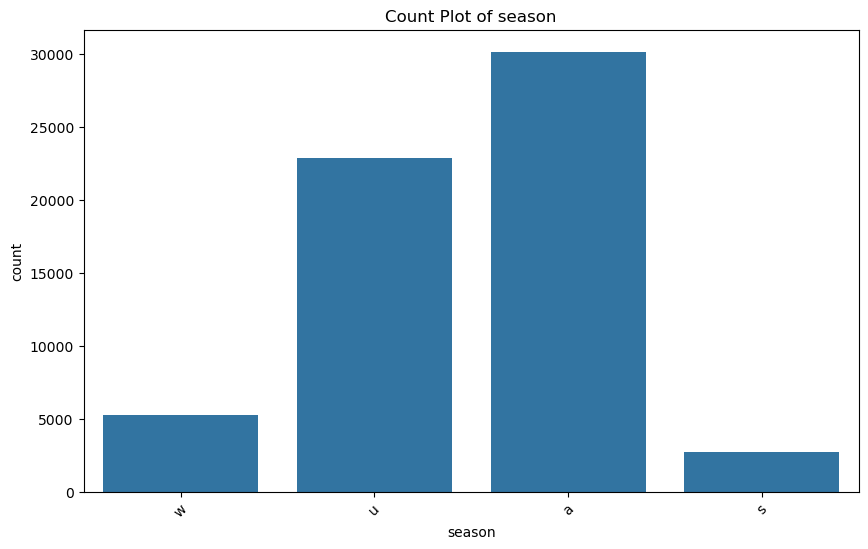

In [8]:
# Masukan fitur-fitur kategorikal pada list dibawah
cols_to_plot = ['class', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color',
       'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']

# Buatkan plot untuk visualisasi masing-masing fitur kolom yang dipilih!
for col in cols_to_plot:
       plt.figure(figsize=(10, 6))
       sns.countplot(data=df, x=col)
       plt.title(f'Count Plot of {col}')
       plt.xticks(rotation=45)
       plt.show()

##### Analisis Fitur Numerik

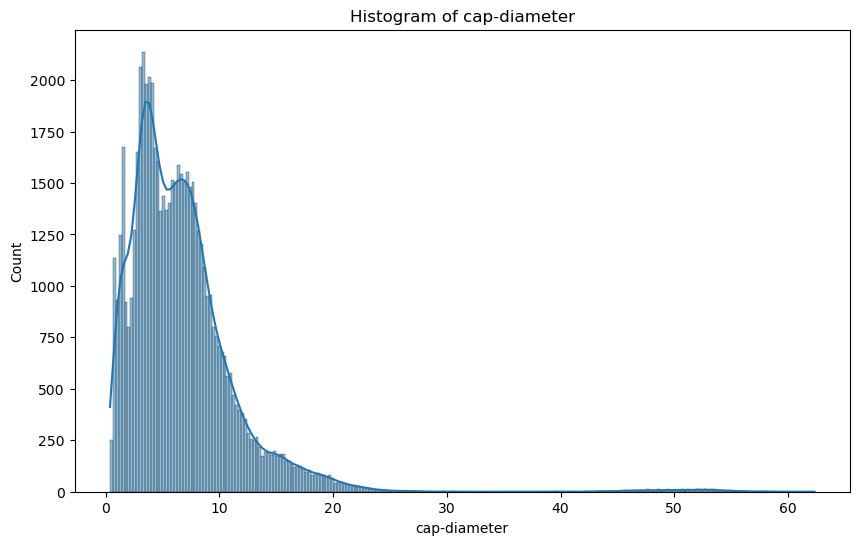

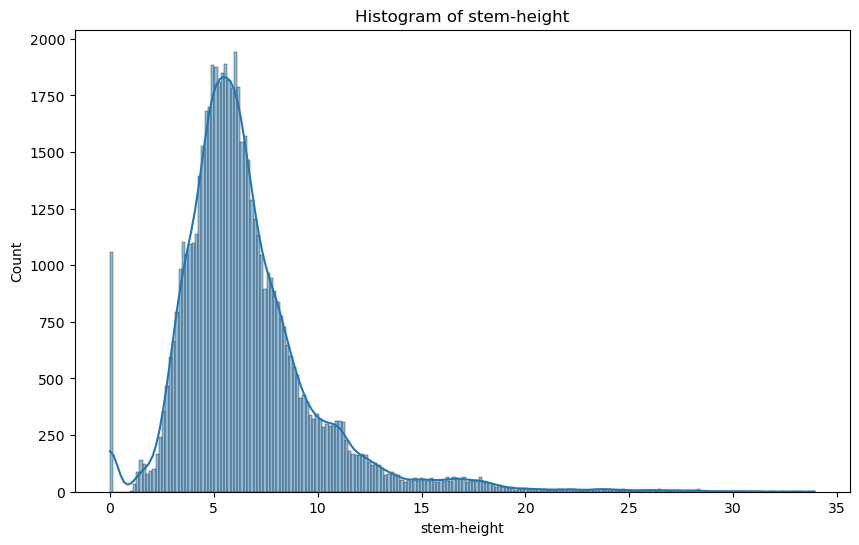

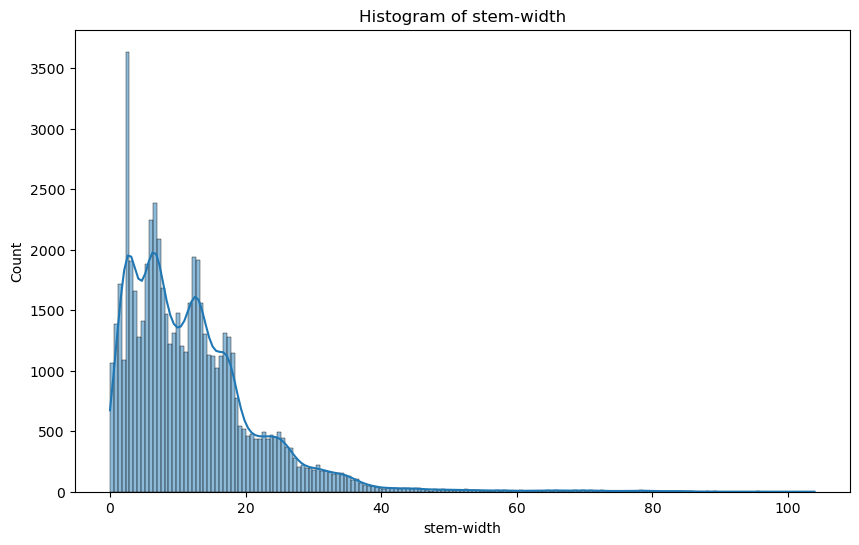

In [9]:
# Masukan fitur-fitur numerik pada list dibawah
numerikal = ['cap-diameter', 'stem-height', 'stem-width']

# Buatkan plot untuk visualisasi masing-masing fitur kolom dengan plot distribusi (Histogram atau KDE)
for col in numerikal:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

## Pemrosesan Data

#### Penanganan Missing Values
  - Lakukan pengecekan apakah terdapat missing values pada dataset.
  - Jika ada:
    - Sebutkan kolom yang memiliki missing values.
    - Tentukan metode penanganannya (misalnya drop atau imputasi dengan "unknown").
  - Jika tidak ada:
    - Jelaskan mengapa langkah ini tetap penting dilakukan dalam preprocessing.
    

Jawaban: Kolom yang memiliki missing values adalah cap-surface, gill-attachment, gill-spacing, stem-root, stem-surface, veil-type, veil-color, ring-type, dan spore-print-color. Penanganannya adalah dengan imputasi dengan 'unknown' untuk fitur objek dan dengan median untuk fitur numerikal.

In [10]:
print(df.isnull().sum())

class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64


In [11]:
# 1. Menghapus fitur dengan missing values > 80%
mv_col = df.isna().mean()
df = df.loc[:, mv_col <= 0.8]

# # 2. Mengisi missing values pada numerik dengan median sebelum di-binning
kolom_num = df.select_dtypes(include=['float64']).columns
for kolom in kolom_num:
    df[kolom].fillna(df[kolom].median(), inplace=True)

# # 3. Mengisi missing values pada kategorikal dengan 'Unknown'
kolom_obj = df.select_dtypes(include=['object']).columns
for kolom in kolom_obj:
    df[kolom].fillna('Unknown', inplace=True)

print(df.isnull().sum())

class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-surface            0
stem-color              0
has-ring                0
ring-type               0
habitat                 0
season                  0
dtype: int64


C:\Users\hassa\AppData\Local\Temp\ipykernel_50808\3277003813.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[kolom].fillna(df[kolom].median(), inplace=True)
C:\Users\hassa\AppData\Local\Temp\ipykernel_50808\3277003813.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

#### Binning Data Numerik
* Lakukan analisis pada fitur-fitur numerik (seperti cap-diameter, stem-height, dan stem-width) untuk menentukan rentang nilai yang sesuai.
* Transformasi Data:
  * Ubah fitur numerik kontinu tersebut menjadi data kategorikal menggunakan metode Binning (misalnya membagi menjadi kategori 'Small', 'Medium', dan 'Large').
  * Jelaskan alasan Anda memilih jumlah bin tertentu atau metode pembagian (quantile vs uniform) yang digunakan.

In [12]:
# Melakukan Binning pada data numerik menjadi 3 kategori (Small, Medium, Large)
# Menggunakan pd.qcut untuk memastikan jumlah data di setiap bin seimbang (Quantile-based)
for col in kolom_num:
    df[col + '_bin'] = pd.qcut(df[col], q=3, labels=['Small', 'Medium', 'Large'])

print("\nHasil Binning pada Fitur Numerik:")
for col in kolom_num:
    print(f"\n{col}_bin:")
    print(df[col + '_bin'].value_counts())


Hasil Binning pada Fitur Numerik:

cap-diameter_bin:
cap-diameter_bin
Small     20367
Medium    20364
Large     20338
Name: count, dtype: int64

stem-height_bin:
stem-height_bin
Small     20464
Large     20331
Medium    20274
Name: count, dtype: int64

stem-width_bin:
stem-width_bin
Medium    20371
Small     20358
Large     20340
Name: count, dtype: int64


#### Train-Test Split

Lakukan pembagian dataset menjadi dua bagian utama, yaitu data latih (*training set*) dan data uji (*test set*).

- Tentukan rasio pembagian data, misalnya:
  - 80% data latih
  - 20% data uji
- Gunakan parameter `random_state` (misalnya `101`) saat melakukan pembagian data.

In [13]:
from sklearn.model_selection import train_test_split

# Membagi dataset menjadi 80% Training dan 20% Testing
data_latih, data_uji = train_test_split(df, test_size=0.2, random_state=42)

# Reset index agar rapi
df = df.reset_index(drop=True)

# Tampilkan jumlah baris masing-masing data yang dipisah
print(f"\nData Latih: {data_latih.shape[0]} baris")
print(f"Data Uji: {data_uji.shape[0]} baris")


Data Latih: 48855 baris
Data Uji: 12214 baris


# Bagian 2: Implementasi Decision Tree Manual
1. Fungsi Kriteria Percabangan:
   - Buat fungsi `hitung_gini`

2. Pembentukan Tree:
   - Implementasikan fungsi rekursif `buat_tree`

In [14]:
import numpy as np
import pandas as pd

# 1. Fungsi untuk menghitung Gini Impurity pada satu kumpulan label
def hitung_gini(kolom_kelas):
    # Menghitung probabilitas setiap kelas (p_i)
    elemen, banyak = np.unique(kolom_kelas, return_counts=True)

    # Rumus Gini: 1 - sum(p_i^2)
    gini = 1 - np.sum([(banyak[i] / np.sum(banyak)) ** 2 for i in range(len(elemen))])
    return gini

# 2. Fungsi untuk menghitung nilai Gini Split (Weighted Gini) dari sebuah fitur
def gini_split(data, nama_fitur_split, nama_fitur_kelas):
    # Mendapatkan nilai unik dari fitur yang akan di-split
    nilai_fitur = np.unique(data[nama_fitur_split])
    total_data = len(data)
    weighted_gini = 0

    for nilai in nilai_fitur:
        # Membuat subset data berdasarkan nilai fitur tertentu
        subset = data[data[nama_fitur_split] == nilai]

        # Hitung gini untuk subset tersebut
        gini = hitung_gini(subset[nama_fitur_kelas])  

        # Akumulasi weighted gini
        weighted_gini += (len(subset) / total_data) * gini

    return weighted_gini

# 3. Fungsi rekursif untuk membangun pohon keputusan (Decision Tree)
def buat_tree(data, data_awal, daftar_fitur, nama_fitur_kelas, kelas_parent_node=None):
    # 1. Jika data kosong, kembalikan kelas mayoritas dari data awal
    if len(data) == 0:
        return np.unique(data_awal[nama_fitur_kelas])[np.argmax(np.unique(data_awal[nama_fitur_kelas],return_counts=True)[1])]

    # 2. Jika semua data memiliki label yang sama, kembalikan label tersebut
    elif len(np.unique(data[nama_fitur_kelas])) <= 1:
        return np.unique(data[nama_fitur_kelas])[0]

    # 3. Jika fitur habis, kembalikan kelas mayoritas pada node saat ini
    elif len(daftar_fitur) == 0:
        return kelas_parent_node

    else:
        # Tentukan kelas mayoritas saat ini untuk jaga-jaga (parent node)
        kelas_default = np.unique(data[nama_fitur_kelas])[np.argmax(np.unique(data[nama_fitur_kelas],return_counts=True)[1])]

        # Cari fitur terbaik dengan Gini Split terendah
        item_gini = [gini_split(data, fitur, nama_fitur_kelas) for fitur in daftar_fitur]
        fitur_terbaik = daftar_fitur[np.argmin(item_gini)]

        # Inisialisasi struktur pohon (dictionary)
        tree = {fitur_terbaik:{}}

        # Hapus fitur terbaik dari daftar fitur untuk level selanjutnya
        daftar_fitur = [i for i in daftar_fitur if i != fitur_terbaik]

        # Bangun cabang untuk setiap nilai unik pada fitur terbaik
        for nilai in np.unique(data[fitur_terbaik]):
            subset = data[data[fitur_terbaik] == nilai] 

            # Panggil rekursi
            sub_tree = buat_tree(subset, data_awal, daftar_fitur, nama_fitur_kelas, kelas_default) 
            tree[fitur_terbaik][nilai] = sub_tree

        return tree

# 4. Fungsi untuk memprediksi data baru berdasarkan pohon yang sudah dilatih
def prediksi(data_uji_row, tree):
    # Melakukan penelusuran pohon (Tree Traversal)
    for key in tree:
        nilai_fitur = data_uji_row.get(key, None)
        if nilai_fitur not in tree[key]:
            return None
        
        # Ambil cabang berdasarkan nilai fitur data uji
        tree = tree[key][nilai_fitur]

        # Jika hasilnya masih berupa dictionary, terus telusuri ke bawah
        if isinstance(tree, dict):
            return prediksi(data_uji_row, tree)
        else:
            # Jika mencapai leaf node (string/label), kembalikan hasilnya
            return tree

In [15]:
# Lakukan training dan testing untuk model Decision Tree
kolom_exclude = ['class', 'cap-diameter', 'stem-height', 'stem-width']
fitur = [col for col in data_latih.columns if col not in kolom_exclude]

tree = buat_tree(data_latih, data_latih, fitur, 'class')

# Bagian 3: Prediksi dan Evaluasi
1. Fungsi Prediksi:
   - Implementasikan fungsi `prediksi` menggunakan traversal tree
2. Evaluasi Model:
   - Hitung jumlah prediksi benar dan salah
   - Bandingkan dengan label asli
   - Tampilkan Struktur Treenya!

#### Tampilkan Struktur Treenya!

In [16]:
from pprint import pprint
pprint(tree)

{'stem-color': {'b': 'e',
                'e': {'cap-surface': {'Unknown': 'p',
                                      'd': {'gill-attachment': {'a': 'e',
                                                                'd': 'p',
                                                                'p': 'e'}},
                                      'e': 'p',
                                      'g': 'p',
                                      'h': 'e',
                                      'i': 'p',
                                      's': 'e',
                                      't': 'e',
                                      'y': 'p'}},
                'f': 'p',
                'g': {'gill-attachment': {'a': {'cap-shape': {'b': {'cap-surface': {'Unknown': 'p',
                                                                                    'g': 'e'}},
                                                              'c': 'e',
                                                              'f

In [17]:
# 1. Melakukan prediksi untuk seluruh baris pada data_uji
# Karena fungsi prediksi() sebelumnya didesain untuk satu baris, kita gunakan .apply
hasil_prediksi = data_uji.apply(lambda row: prediksi(row, tree), axis=1)

# 2. Melengkapi fungsi evaluasi_model
def evaluasi_model(prediksi, label_uji):
  # Mapping sederhana: 'e' jadi 0, 'p' jadi 1.
  # None (data tak dikenal) otomatis dipetakan ke 1 ('p') agar aman.
  mapping = {'e': 0, 'p': 1, None: 1}

  # Mengonversi list label menjadi numerik menggunakan map biasa
  y_pred_num = [mapping.get(p, 1) for p in prediksi]
  y_true_num = [mapping.get(y, 1) for y in label_uji]

  skor_akurasi = accuracy_score(y_true_num, y_pred_num)
  skor_presisi = precision_score(y_true_num, y_pred_num)
  skor_recall = recall_score(y_true_num, y_pred_num)
  skor_f1 = f1_score(y_true_num, y_pred_num)

  # Perhitungan metrics menggunakan hasil mapping numerik
  print(f"Skor akurasi: {skor_akurasi}")
  print(f"Skor presisi: {skor_presisi}")
  print(f"Skor recall: {skor_recall}")
  print(f"F1-score: {skor_f1:.4f}")

# 3. Menjalankan evaluasi
# Pastikan label_uji adalah kolom 'class' dari data uji Anda
evaluasi_model(hasil_prediksi, data_uji['class'])

Skor akurasi: 1.0
Skor presisi: 1.0
Skor recall: 1.0
F1-score: 1.0000


## Pertanyaan

### 1. Kondisi Berhenti pada Pembentukan Tree
Fungsi `buat_tree` bekerja secara rekursif untuk membentuk cabang. Apa yang terjadi pada data di sebuah node sehingga algoritma memutuskan untuk berhenti membuat cabang dan menetapkan node tersebut sebagai *leaf node* (titik akhir)?

---

### 2. Penentuan Root Node
Dalam algoritma Decision Tree, terdapat istilah *root node*. Berdasarkan kode yang Anda buat, bagaimana cara menentukan fitur mana yang paling layak ditempatkan sebagai *root node* (akar pohon)?

---

### 3. Mekanisme Prediksi pada Nested Dictionary
Struktur model yang dibuat disimpan dalam bentuk *nested dictionary* (kamus bersarang).

Jelaskan bagaimana cara fungsi `prediksi` menelusuri struktur tersebut untuk menghasilkan keputusan akhir, misalnya menentukan apakah sebuah jamur beracun atau tidak.

---

### 4. Penanganan Nilai yang Tidak Pernah Muncul
Jika model dihadapkan pada data uji yang memiliki nilai fitur yang belum pernah muncul saat pelatihan (misalnya kategori baru pada suatu fitur), apa yang akan dilakukan oleh fungsi `prediksi` untuk menghindari error?

Jelaskan strategi yang digunakan untuk menangani kondisi tersebut.

## Jawaban

### 1. Kondisi Berhenti pada Tree
Algoritma menghentikan pembentukan cabang dan menetapkan sebuah node sebagai leaf node ketika data pada node sudah homogen (hanya satu kelas), data pada node kosong, atau tidak ada fitur yang tersisa untuk di-split.

---

### 2. Penentuan Root Node
Fitur yang dipilih sebagai root node adalah fitur dengan kualitas pemisahan terbaik. Pada implementasi ini, kualitas split diukur dengan Gini Split, sehingga root dipilih dari fitur dengan nilai Gini Split paling kecil (terendah).

---

### 3. Mekanisme Prediksi
Fungsi prediksi bekerja dengan menelusuri pohon secara top-down mulai dari root node hingga mencapai leaf node. Program mengecek nilai fitur pada data uji, memilih cabang yang sesuai, lalu mengulang proses sampai leaf node dan label pada leaf node menjadi hasil prediksi.

---

### 4. Penanganan Nilai Baru (Unseen Values)
Jika ditemukan nilai fitur yang tidak pernah muncul saat training, fungsi `prediksi` tidak melempar error dan tidak mengembalikan `None`, tetapi langsung menggunakan `kelas_default` (kelas mayoritas data latih) sebagai fallback. Strategi ini menjaga proses prediksi tetap stabil pada kategori baru.